In [13]:
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask
import xarray as xr
import matplotlib.colors as colors

import bed

In [14]:
bed.__version__

'0.0.0'

In [15]:
# Get example data (uncomment if not yet downloaded)
# data_folder = bed.get_data()
data_folder = '../downloaded_data/examples/'

In [16]:
config_file = os.path.join(data_folder, "example_config.yml")

In [17]:
example_bed = bed.Bed(config_file)

2024-07-18 16:12:30,474 - INFO - Starting class Data inside module read_data...
2024-07-18 16:12:30,476 - INFO - Starting function read_config...
2024-07-18 16:12:30,483 - INFO - Function read_config complete.
2024-07-18 16:12:30,484 - INFO - Reading RES_base_year_building_area_data data
2024-07-18 16:12:30,537 - INFO - Reading NRES_base_year_building_area_data data
2024-07-18 16:12:30,567 - INFO - Reading base_year_temperature_data data
2024-07-18 16:12:36,987 - INFO - Reading RES_base_year_building_area_data data
2024-07-18 16:12:37,027 - INFO - Reading NRES_base_year_building_area_data data
2024-07-18 16:12:37,061 - INFO - Reading base_year_building_height_data data
2024-07-18 16:12:37,098 - INFO - Reading base_year_income_per_capita data
2024-07-18 16:12:37,116 - INFO - Reading RES_u_factor_data data
2024-07-18 16:12:37,128 - INFO - Reading NRES_u_factor_data data
2024-07-18 16:12:37,145 - INFO - Calculating surface area to floor space ratio
2024-07-18 16:12:37,154 - INFO - Calcula

# Exploring with output

In [18]:
misc_data_path = '/Users/prim232/data/nasa_lulc'
cities_mask = gpd.read_file(os.path.join(misc_data_path, 'Shapefiles demanded/Cities Shapefiles'))

In [19]:
heating_demand = example_bed.energy_demand[2018]['resid']['demand_h'].compute()
cooling_demand = example_bed.energy_demand[2018]['resid']['demand_c'].compute()

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

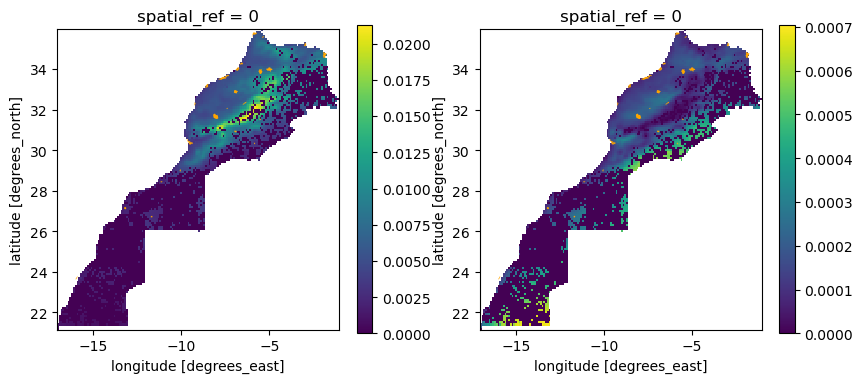

In [20]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
heating_demand.plot(ax=ax1)
cooling_demand.plot(ax=ax2)
cities_mask.plot(ax=ax1, color='orange')
cities_mask.plot(ax=ax2, color='orange')

In [25]:
total_heating_demand = heating_demand * example_bed.data.data_dict[2018]['resid_floor_space']
total_cooling_demand = cooling_demand * example_bed.data.data_dict[2018]['resid_floor_space']

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

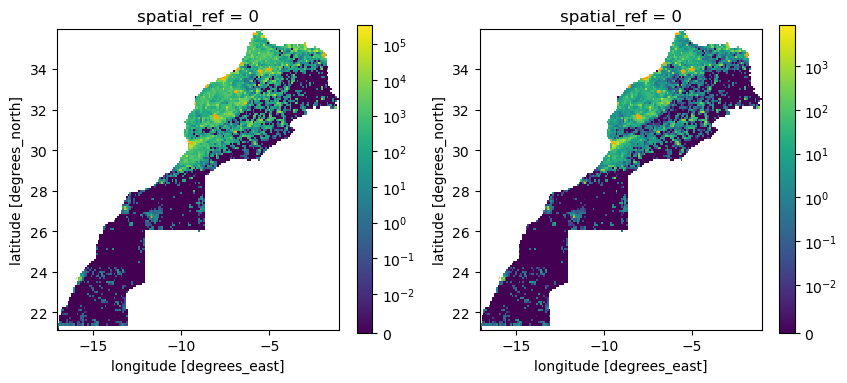

In [26]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
total_heating_demand.plot(ax=ax1, norm=colors.SymLogNorm(linthresh=1e-2))
total_cooling_demand.plot(ax=ax2, norm=colors.SymLogNorm(linthresh=1e-2))
cities_mask.plot(ax=ax1, color='orange')
cities_mask.plot(ax=ax2, color='orange')

In [30]:
# Get masks for regions
region_masks = regionmask.mask_3D_geopandas(cities_mask, heating_demand.x, heating_demand.y, drop=False)

# Mask data
masked_heating_demand = heating_demand.where(region_masks).copy()
masked_cooling_demand = cooling_demand.where(region_masks).copy()
masked_total_heating_demand = total_heating_demand.where(region_masks).copy()
masked_total_cooling_demand = total_cooling_demand.where(region_masks).copy()

In [31]:
# Aggregate by region
masked_heating_demand = masked_heating_demand.mean(("x", "y")).compute()
masked_cooling_demand = masked_cooling_demand.mean(("x", "y")).compute()
masked_total_heating_demand = masked_total_heating_demand.sum(("x", "y")).compute()
masked_total_cooling_demand = masked_total_cooling_demand.sum(("x", "y")).compute()

In [33]:
# Format data
demand_df = pd.DataFrame({
    'region_number': masked_heating_demand.region,
    'heating_demand': masked_heating_demand.values,
    'total_heating_demand': masked_total_heating_demand.values,
    'cooling_demand': masked_cooling_demand.values,
    'total_cooling_demand': masked_total_cooling_demand.values,
    'demand': masked_heating_demand.values + masked_cooling_demand.values,
    'total_demand': masked_total_heating_demand.values + masked_total_cooling_demand.values
})
demand_df = pd.merge(demand_df, cities_mask, left_on='region_number', right_index=True)
demand_df['center'] = [poly.centroid for poly in demand_df['geometry']]

<Axes: xlabel='commune'>

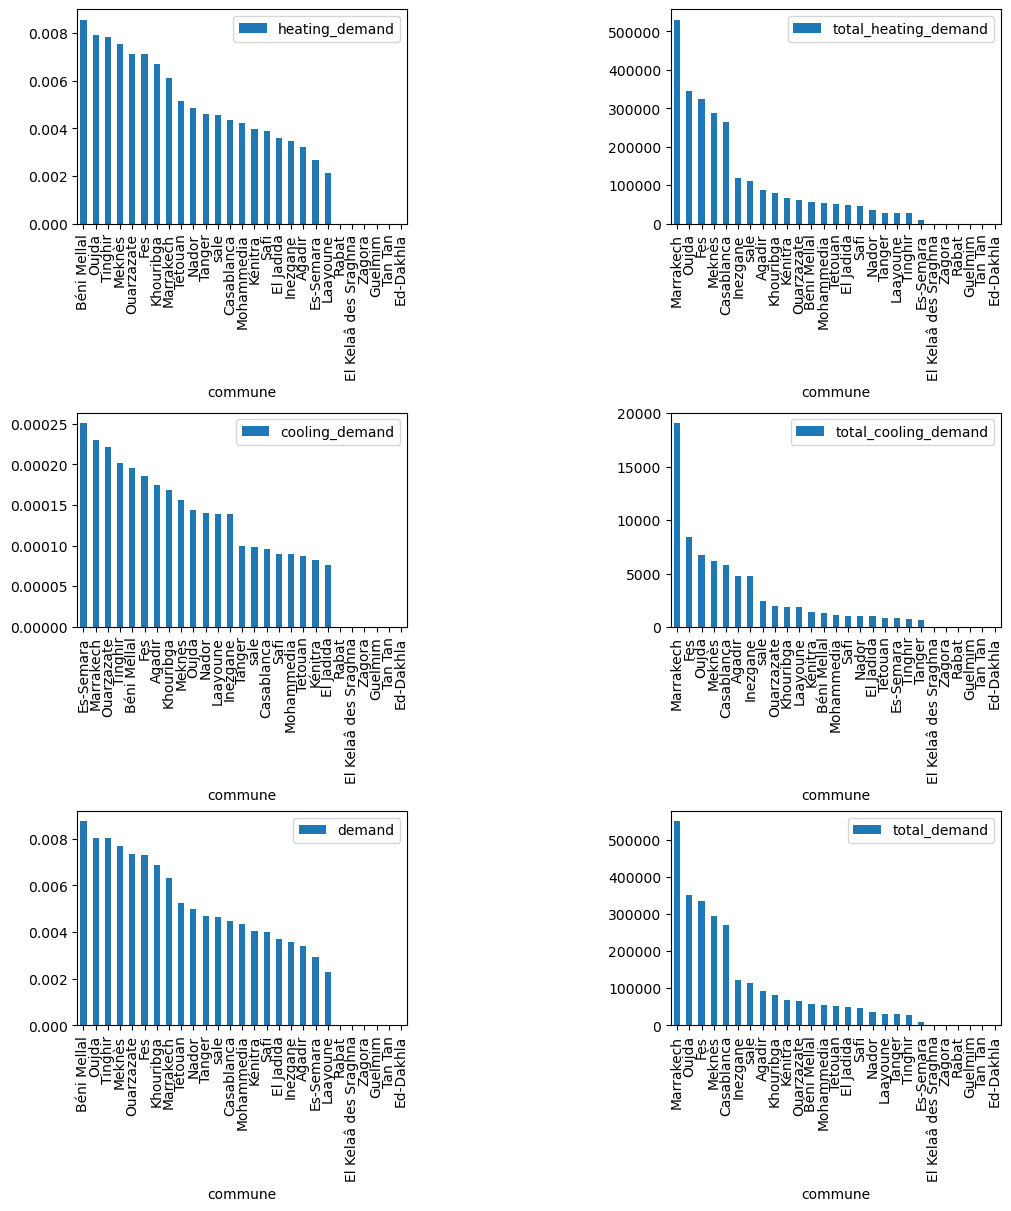

In [36]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(
    3,2, figsize=(10,12),
    gridspec_kw = {
            'wspace': 0.4, 
            'hspace': 0.01
            },
        constrained_layout=True
    )

demand_df.sort_values('heating_demand', ascending=False).plot.bar(ax=ax1, x='commune', y='heating_demand')
demand_df.sort_values('total_heating_demand', ascending=False).plot.bar(ax=ax2, x='commune', y='total_heating_demand')
demand_df.sort_values('cooling_demand', ascending=False).plot.bar(ax=ax3, x='commune', y='cooling_demand')
demand_df.sort_values('total_cooling_demand', ascending=False).plot.bar(ax=ax4, x='commune', y='total_cooling_demand')
demand_df.sort_values('demand', ascending=False).plot.bar(ax=ax5, x='commune', y='demand')
demand_df.sort_values('total_demand', ascending=False).plot.bar(ax=ax6, x='commune', y='total_demand')

Text(0.5, 1.0, 'Cooling Demand Per Unit Floor Space')

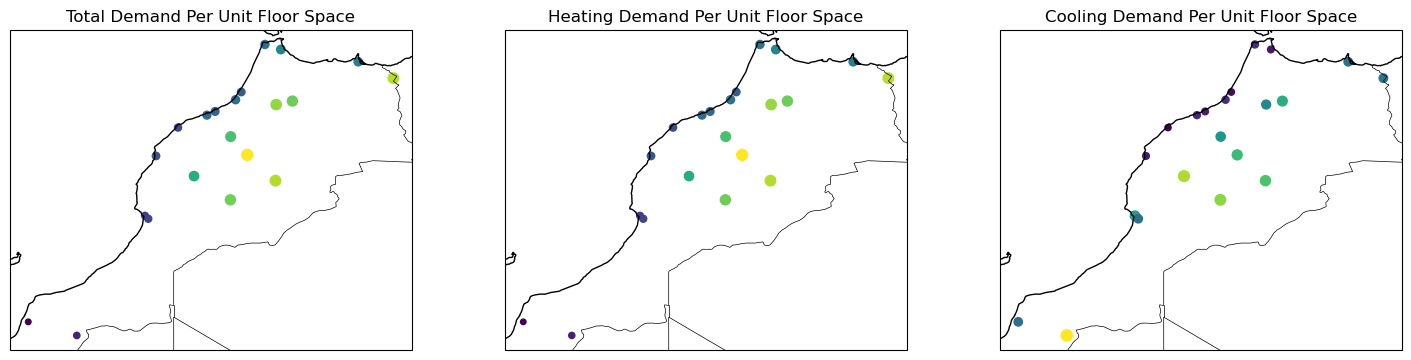

In [92]:
# Extract data
scatter_df = gpd.GeoDataFrame( demand_df[['demand', 'heating_demand', 'cooling_demand', 'region']], geometry = demand_df['center'] )
scatter_df['demand'] = 800 * scatter_df['demand'] / np.sum(scatter_df['demand'])
scatter_df['heating_demand'] = 800 * scatter_df['heating_demand'] / np.sum(scatter_df['heating_demand'])
scatter_df['cooling_demand'] = 800 * scatter_df['cooling_demand'] / np.sum(scatter_df['cooling_demand'])

# Set up figure
fig, axes = plt.subplots(
    1, 3, figsize = (14,4),
    subplot_kw = {'projection': ccrs.PlateCarree()},
    gridspec_kw = {
        'wspace': 0.2, 
        'hspace': 0.01,
        'width_ratios': [1,1,1]
        },
    constrained_layout=True
)

# Plots

# Total demand
scatter_df.plot(
    ax = axes[0],
    column = 'demand', 
    markersize = 'demand',
    legend = False 
)

# Heating Demand
scatter_df.plot(
    ax = axes[1],
    column = 'heating_demand', 
    markersize = 'heating_demand',
    legend = False 
)

# Cooling Demand
scatter_df.plot(
    ax = axes[2],
    column = 'cooling_demand', 
    markersize = 'cooling_demand',
    legend = False 
)

# Add boarders
axes[0].coastlines()
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
axes[1].coastlines()
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
axes[2].coastlines()
axes[2].add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')

# Title
axes[0].set_title('Total Demand Per Unit Floor Space')
axes[1].set_title('Heating Demand Per Unit Floor Space')
axes[2].set_title('Cooling Demand Per Unit Floor Space')